In [1]:
# !pip  install --upgrade transformers huggingface_hub
!pip install --upgrade transformers==4.45.0 huggingface_hub wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 100.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 47.7 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3


In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [3]:
train_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_training_set_1.parquet"
val_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_validation_set.parquet"
test_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_test_set_sample.parquet"

# load train,test & validation data
train_data = pd.read_parquet(train_path)
val_data = pd.read_parquet(val_path)
test_data = pd.read_parquet(test_path)

In [4]:
train_data.head()

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python
3,T = int(input())\nfor t in range(T):\n\tcolor ...,human,0,Python
4,for i in range(int(input())):\n\tinput()\n\ta ...,human,0,Python


In [5]:
val_data.head()

,code,generator,label,language
0,import sys\ninf = float('inf')\nfrom bisect im...,human,0,Python
1,"def Range(a): return min(max(a, -10), 10)\n\nd...",meta-llama/Llama-3.1-8B,1,Python
2,#include<bits/stdc++.h>\n\n\n\nusing namespace...,human,0,C++
3,t = int(input())\nfor _ in range(t):\n\tn = in...,human,0,Python
4,"def subArraySum(arr, n, target_sum):\n coun...",Qwen/Qwen2.5-Coder-32B-Instruct,1,Python


In [6]:
test_data.head()

,code,generator,label,language
0,public Vector To(Vector o)\n {\n ...,Human,0,C#
1,func (v *DefaultMessageSyntaxValidator) Valida...,Human,0,Go
2,"""""""Module managing testsuite capabilities\n\nC...",Human,0,Python
3,void Anvil::Image::on_memory_backing_opaque_up...,Human,0,C++
4,bool NOMAD::Priority_Eval_Point::dominates\n( ...,Human,0,C++


In [7]:
label_to_id = {
  "human": 0,
  "machine": 1
}

In [8]:
print(f"Training Samples:        {len(train_data)}")
print(f"Validation Samples:      {len(val_data)}")
print(f"Test Samples:            {len(test_data)}")

Training Samples:        500000
Validation Samples:      100000
Test Samples:            1000


In [9]:
print("Train shape:", train_data.shape)
print(f"Data column: {train_data.columns.to_list()}")

Train shape: (500000, 4)
Data column: ['code', 'generator', 'label', 'language']


In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   code       500000 non-null  object
 1   generator  500000 non-null  object
 2   label      500000 non-null  int64 
 3   language   500000 non-null  object
dtypes: int64(1), object(3)
memory usage: 15.3+ MB


## **Checking For Missing Values**

In [11]:
# checking missing value in train_dataset
train_data.isnull().sum()

code         0
generator    0
label        0
language     0
dtype: int64

In [12]:
# checking missing values in test_dataset
test_data.isnull().sum()

code         0
generator    0
label        0
language     0
dtype: int64

In [13]:
# checking missing values in validation dataset
val_data.isnull().sum()

code         0
generator    0
label        0
language     0
dtype: int64

## **Unique Value Analysis**


In [14]:
train_data.nunique()

code         500000
generator        35
label             2
language          3
dtype: int64

In [15]:
train_data["language"].value_counts()

language
Python    457306
C++        23392
Java       19302
Name: count, dtype: int64

## checking for balance dataset

In [16]:

train_data["label"].value_counts()

label
1    261525
0    238475
Name: count, dtype: int64

## Label Distribution (Human vs Machine)

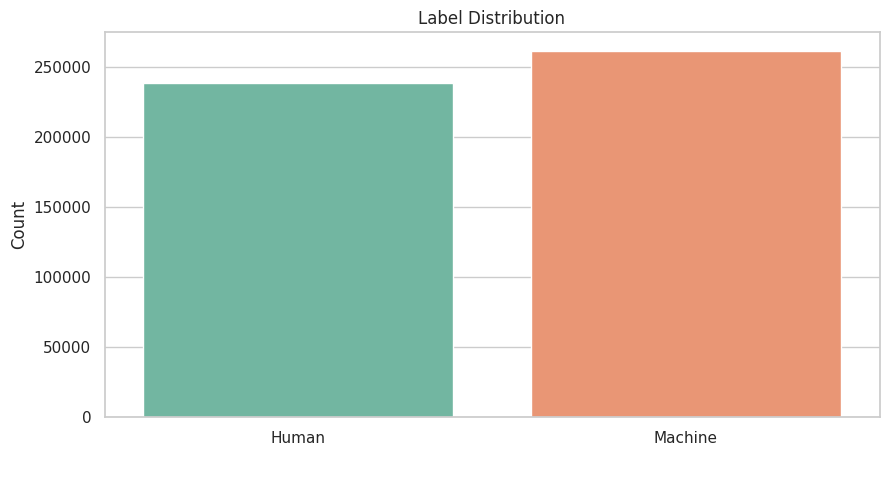

label
1    52.3
0    47.7
Name: count, dtype: float64

In [110]:

# Create folder if it doesn't exist
os.makedirs("plots", exist_ok=True)

label_counts = train_data["label"].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values,palette="Set2")
plt.title("Label Distribution")
plt.xlabel(" ")
plt.ylabel("Count")
plt.xticks([0,1], ["Human", "Machine"])


# Save figure as PDF
plt.savefig("plots/label_distribution_human_vs_machine.pdf", bbox_inches="tight")

plt.show()


# percentage of Machine and Human generated code
(label_counts / len(train_data) * 100).round(2)

## Generator Frequency (for machine label)

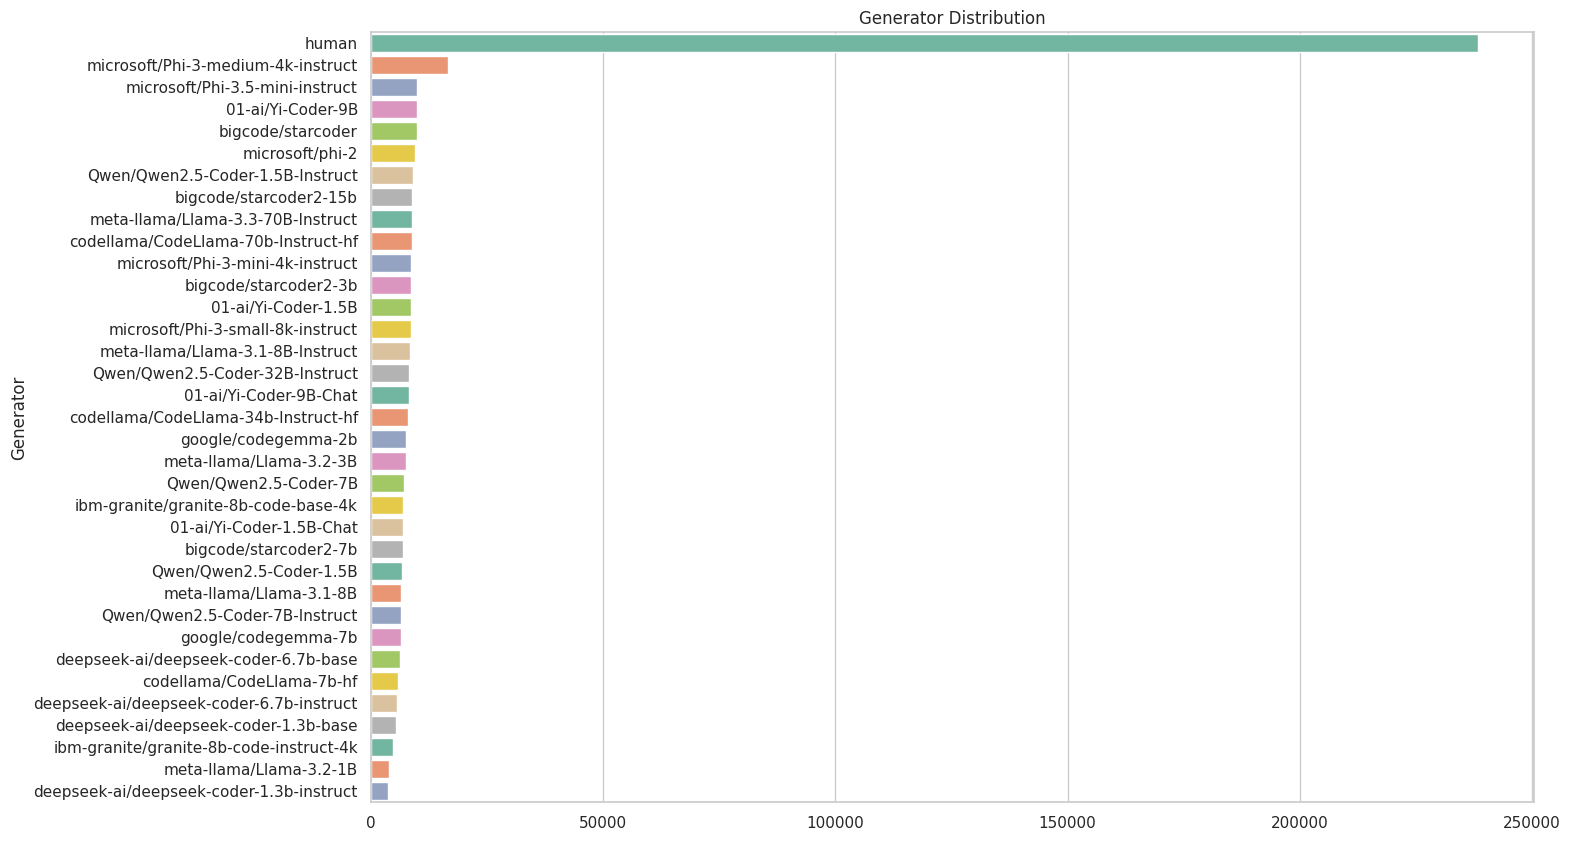

In [108]:
# Generator Distribution
plt.figure(figsize=(15, 10))
top_gen = train_data["generator"].value_counts()
sns.barplot(y=top_gen.index, x=top_gen.values,palette="Set2")
plt.title("Generator Distribution")
plt.xlabel(" ")
plt.ylabel("Generator")
# Save figure as PDF
plt.savefig("plots/generator_distribution.pdf", bbox_inches="tight")

plt.show()

## Distribution by Programming Language

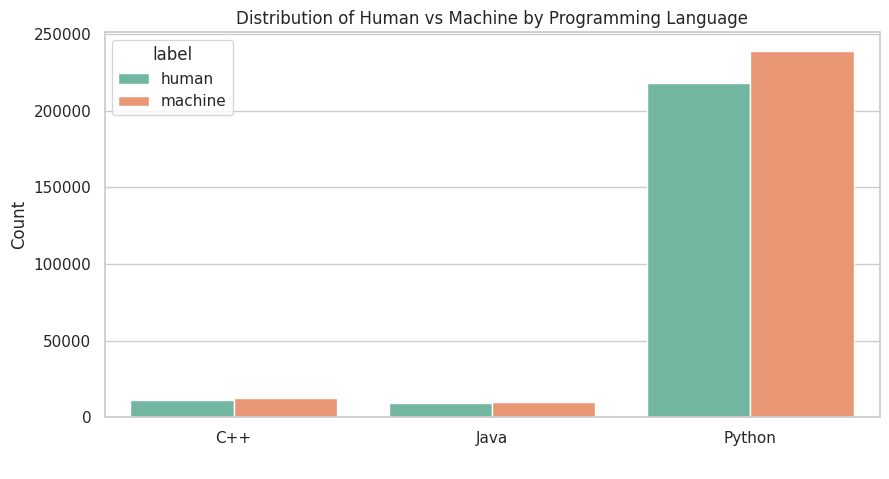

In [117]:
# Crosstab (language × label)
ct = pd.crosstab(train_data["language"], train_data["label"])

# Reset index so Seaborn can use it
ct = ct.reset_index()

# Melt into long format for seaborn
ct_melted = ct.melt(id_vars="language",
                    var_name="label",
                    value_name="count")

# Optional: rename labels only for the plot
ct_melted["label"] = ct_melted["label"].map({0: "human", 1: "machine"})


sns.barplot(
    data=ct_melted,
    x="language",
    y="count",
    hue="label",
    palette="Set2"
  
)

plt.title("Distribution of Human vs Machine by Programming Language")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xlabel(" ")
plt.savefig("plots/programming_language_distribution.pdf", bbox_inches="tight")
plt.show()


## Compute Characters count for each code snippet

Code length statistics
This helps see whether AI-generated code tends to be longer/shorter.

Min code Characters length: 0
Max code Characters length: 475006


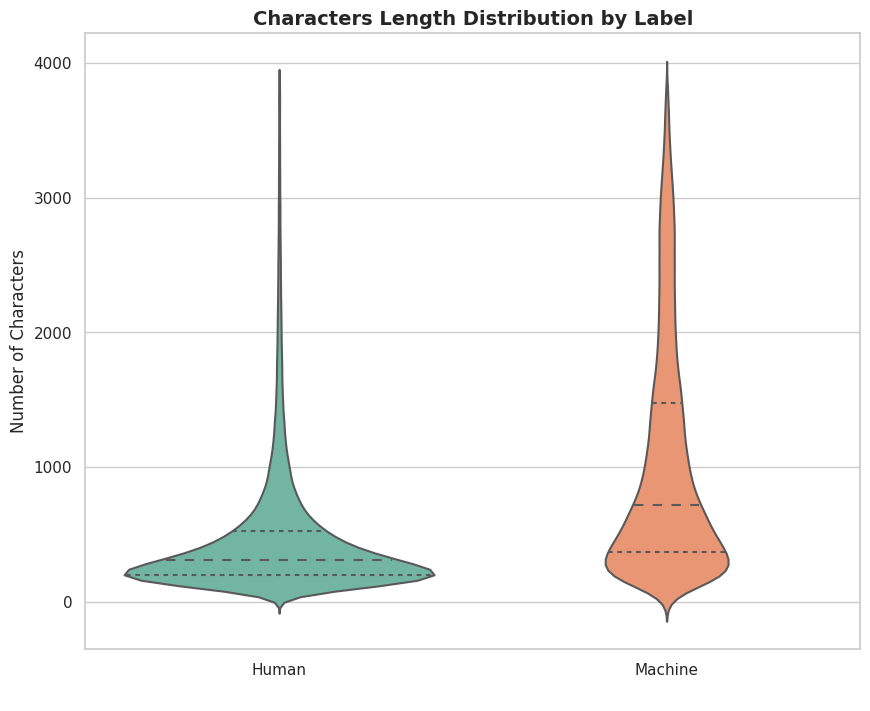

In [112]:

# Compute character length if not already done
train_data["code_length"] = train_data["code"].astype(str).str.len()
filtered = train_data[train_data["code_length"] < train_data["code_length"].quantile(0.99)]

print("Min code Characters length:", train_data["code_length"].min())
print("Max code Characters length:", train_data["code_length"].max())

plt.figure(figsize=(10,8))
sns.violinplot(
    x="label",
    y="code_length",
    data=filtered,
    inner="quartile",
    palette="Set2"
    
)
plt.xticks([0,1], ["Human", "Machine"])
plt.title("Characters Length Distribution by Label", fontsize=14, weight='bold')
plt.ylabel("Number of Characters", fontsize=12)
plt.xlabel(" ")
plt.savefig("plots/character_length_distribution.pdf", bbox_inches="tight")
plt.show()

In [21]:
# train_data["code_length"] = train_data["code"].astype(str).str.len()
print(train_data["code_length"].describe())


count    500000.000000
mean        836.865392
std        1372.762958
min           0.000000
25%         255.000000
50%         464.000000
75%        1011.000000
max      475006.000000
Name: code_length, dtype: float64


## camelCase vs snake_case usage between human and machine-generated code

In [55]:
import re
camel_case_pattern = r'\b[a-z]+(?:[A-Z][a-z0-9]+)+\b'     # e.g. myVariable, totalScoreValue
snake_case_pattern = r'\b[a-z]+(?:_[a-z0-9]+)+\b'         # e.g. my_variable, total_score


def count_camel_case(text):
    return len(re.findall(camel_case_pattern, text))

def count_snake_case(text):
    return len(re.findall(snake_case_pattern, text))


train_data['camel_count'] = train_data['code'].astype(str).apply(count_camel_case)
train_data['snake_count'] = train_data['code'].astype(str).apply(count_snake_case)

train_data['total_idents'] = train_data['camel_count'] + train_data['snake_count']
train_data['camel_ratio'] = train_data['camel_count'] / (train_data['total_idents'] + 1e-5)
train_data['snake_ratio'] = train_data['snake_count'] / (train_data['total_idents'] + 1e-5)



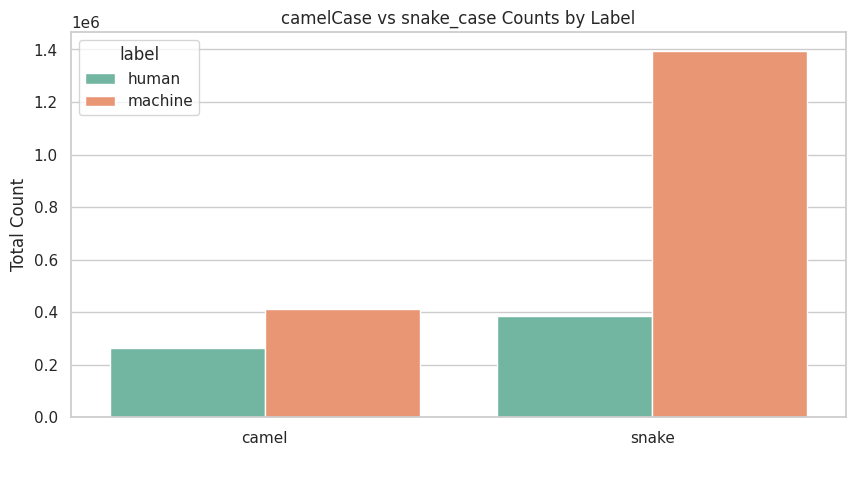

In [113]:

# Sum camel and snake counts per label (human vs model)
summary = train_data.groupby("label")[["camel_count", "snake_count"]].sum()


# Convert to long format for seaborn
summary = summary.reset_index().melt(
    id_vars="label",
    value_vars=["camel_count", "snake_count"],
    var_name="case_type",
    value_name="count"
)

# Clean case_type names
summary["case_type"] = summary["case_type"].str.replace("_count", "")

summary["label"] = summary["label"].map({0: "human", 1: "machine"})

sns.barplot(
    data=summary,
    x="case_type",
    y="count",
    hue="label",
    palette="Set2"
)

plt.title("camelCase vs snake_case Counts by Label")
plt.ylabel("Total Count")
plt.xlabel(" ")
# Save figure as PDF
plt.savefig("plots/camelCase_vs_snake_case.pdf", bbox_inches="tight")
plt.show()

## Keyword / token analysis
Top tokens in human vs machine

In [24]:
def get_token_frequencies(text_series, ngram_range=(1,1), stop_words=None):
    vectorizer = CountVectorizer(stop_words=stop_words, ngram_range=ngram_range)
    bow = vectorizer.fit_transform(text_series)

    token_counts = np.array(bow.sum(axis=0)).flatten()
    tokens = vectorizer.get_feature_names_out()

    df = pd.DataFrame({
        "token": tokens,
        "frequency": token_counts
    }).sort_values(by="frequency", ascending=False)

    return df, vectorizer


In [25]:
human_code = train_data[train_data["generator"] == "human"]["code"]
ai_code = train_data[train_data["generator"] != "human"]["code"]

human_freq_df, human_vec = get_token_frequencies(human_code)
ai_freq_df, ai_vec = get_token_frequencies(ai_code)


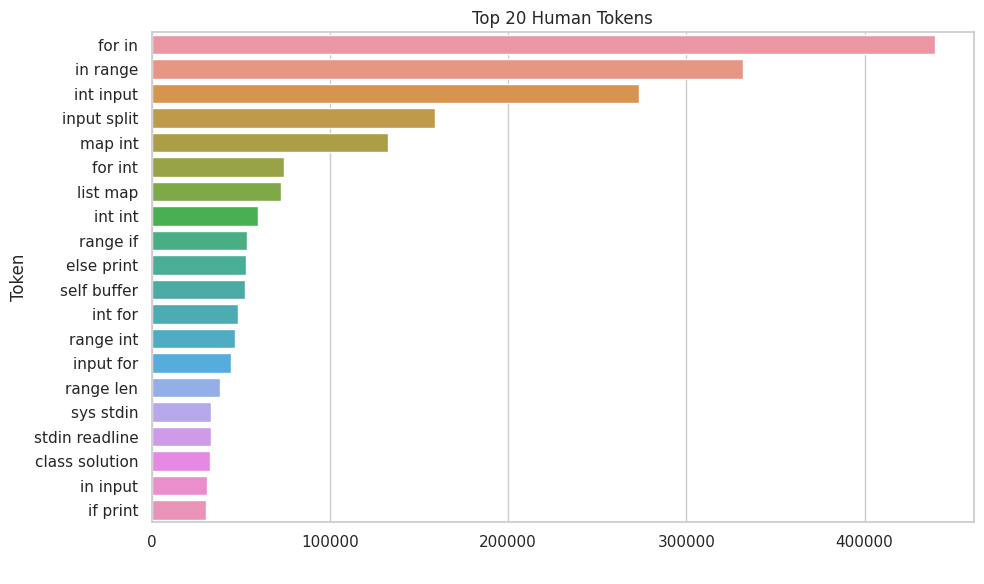

In [115]:
def plot_top_tokens(freq_df, top_n=20, title="Top Tokens"):
    top_df = freq_df.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_df,
        y="token",
        x="frequency",
        
    )

    plt.title(title)
    plt.xlabel(" ")
    plt.ylabel("Token")
    plt.tight_layout()

    # plt.savefig(f"plots/{title.replace(" ", "_") + ".pdf"}", bbox_inches="tight")
    plt.savefig(f"plots/{title.replace(' ', '_')}.pdf", bbox_inches="tight")
    

    plt.show()


plot_top_tokens(human_freq_df, 20, "Top 20 Human Tokens")



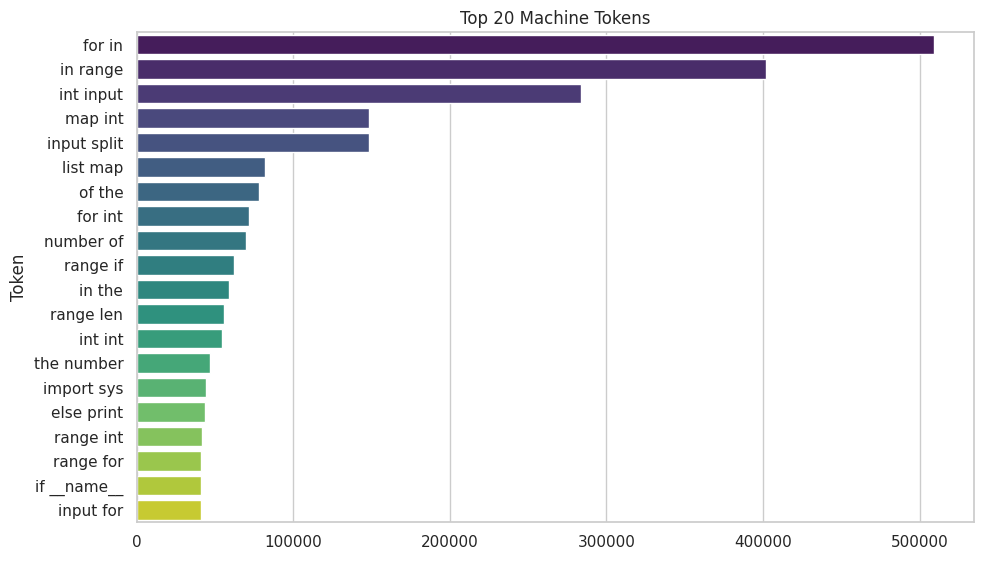

In [33]:
plot_top_tokens(ai_freq_df, 20, "Top 20 Machine Tokens")


## For any N-grams
+ for  N-grams (like for i, def func, etc.)
+ human_freq_df, _ = get_token_frequencies(human_code, ngram_range=(1,2))

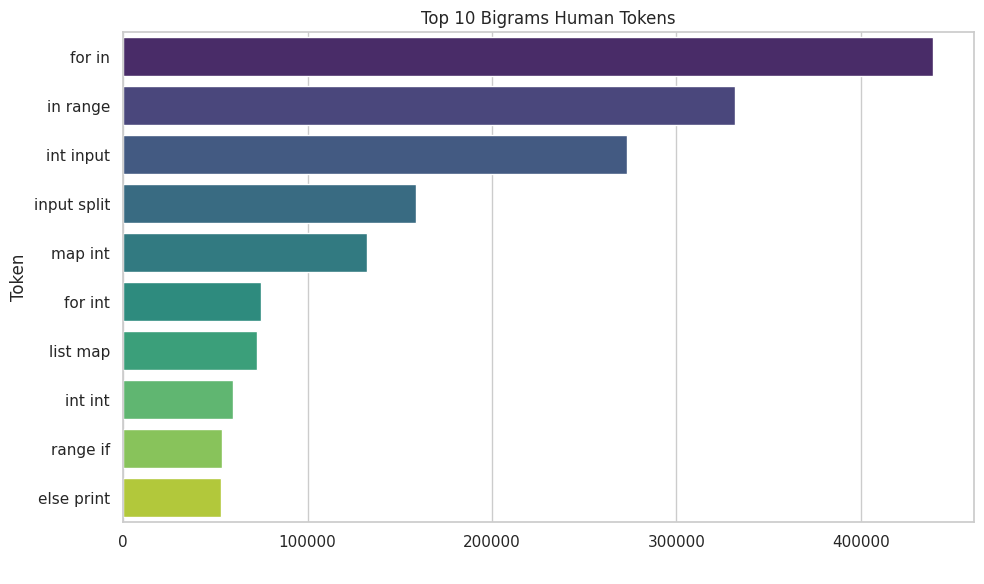

In [34]:
human_freq_df, _ = get_token_frequencies(human_code, ngram_range=(2,2))
plot_top_tokens(human_freq_df, 10, "Top 10 Bigrams Human Tokens")

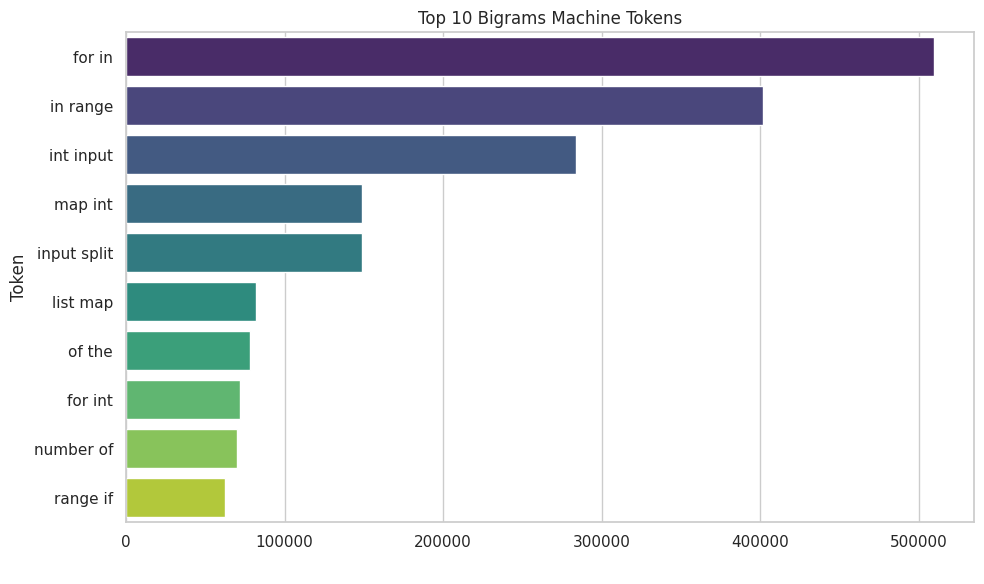

In [35]:
ai_freq_df, ai_vec = get_token_frequencies(ai_code,ngram_range=(2,2))
plot_top_tokens(ai_freq_df, 10, "Top 10 Bigrams Machine Tokens")

## Character-level signals (often helpful to detect AI vs human)

Compute:
+ indentation style (tabs vs spaces)
+ frequency of comments
+ camelCase/snake_case ratios
+ logical operator frequencies (if, while, for patterns)

In [120]:
train_data['num_comments'] = train_data['code'].str.count("#|//")
train_data['num_tabs'] = train_data['code'].str.count("\t")
train_data['num_spaces'] = train_data['code'].str.count("    ")

train_data["num_lines"] = train_data["code"].astype(str).apply(lambda x: x.count("\n") + 1)
train_data["num_defs"] = train_data["code"].astype(str).str.count(r"\bdef\b")
train_data["num_for"] = train_data["code"].astype(str).str.count(r"\bfor\b")
train_data["num_if"] = train_data["code"].astype(str).str.count(r"\bif\b")
train_data["num_import"] = train_data["code"].astype(str).str.count(r"\bimport\b")


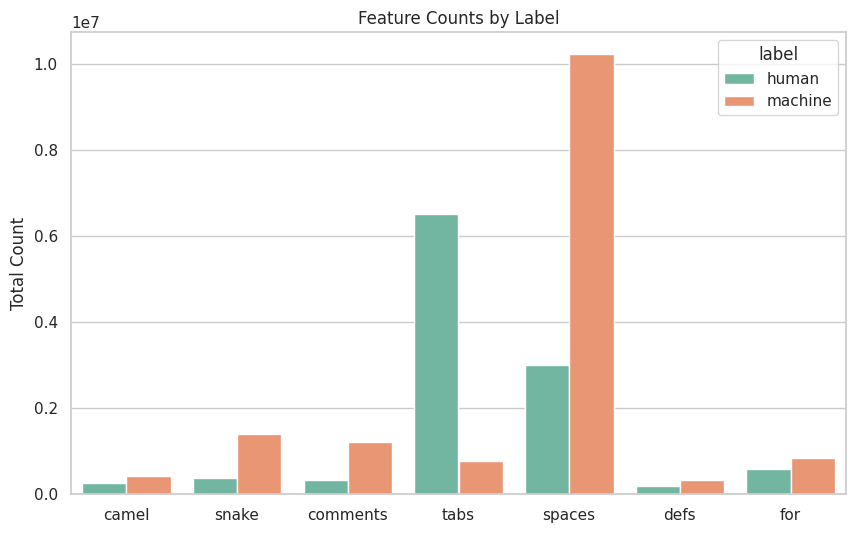

In [125]:
# Sum counts per label
summary = train_data.groupby("label")[["camel_count", "snake_count","num_comments",
                                       "num_tabs","num_spaces","num_defs","num_for"]].sum()

# Convert to long format
summary = summary.reset_index().melt(
    id_vars="label",
    value_vars=["camel_count", "snake_count","num_comments","num_tabs",
                "num_spaces","num_defs","num_for"],
    var_name="feature",
    value_name="count"
)

# Map old column names to clean names
name_map = {
    "camel_count": "camel",
    "snake_count": "snake",
    "num_comments": "comments",
    "num_tabs": "tabs",
    "num_spaces": "spaces",
    "num_defs": "defs",
    "num_for": "for"
}

summary["feature"] = summary["feature"].map(name_map)

# Rename labels only for the plot
summary["label"] = summary["label"].map({0: "human", 1: "machine"})

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(
    data=summary,
    x="feature",
    y="count",
    hue="label",
    palette="Set2"
)

plt.title("Feature Counts by Label")
plt.ylabel("Total Count")
plt.xlabel(" ")
plt.savefig("plots/feature_counts_by_label.pdf", bbox_inches="tight")
plt.show()


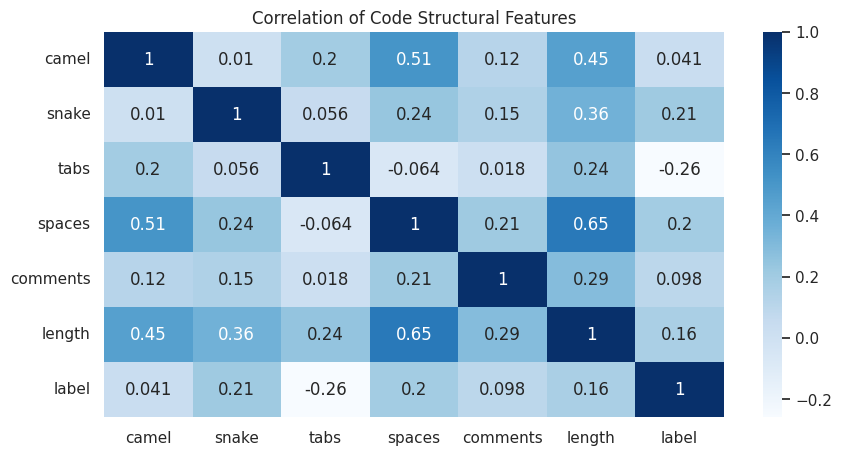

In [127]:
# Heatmap of Structural Features
# Select features
features = ['camel_count','snake_count','num_tabs','num_spaces','num_comments','code_length','label']

# Compute correlation
corr_matrix = train_data[features].corr()

# Map old column names to clean names
name_map = {
    "camel_count": "camel",
    "snake_count": "snake",
    'num_tabs': 'tabs',
    'num_spaces': 'spaces',
    'num_comments': 'comments',
    'code_length': 'length',
    'label': 'label',
}

# Rename rows and columns
corr_matrix.rename(index=name_map, columns=name_map, inplace=True)

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation of Code Structural Features")
plt.savefig("plots/correlation_of_code_structural_features.pdf", bbox_inches="tight")
plt.show()



## Duplicates & Code Leakage Check

In [39]:
total_dupes = train_data.duplicated("code").sum()
dupes = train_data[train_data.duplicated("code", keep=False)]
total_dupes, dupes.head()


(0,
 Empty DataFrame
 Columns: [code, generator, label, language, code_length, num_comments, num_tabs, num_spaces]
 Index: [])

## Advanced: Code Complexity Score
Insight:


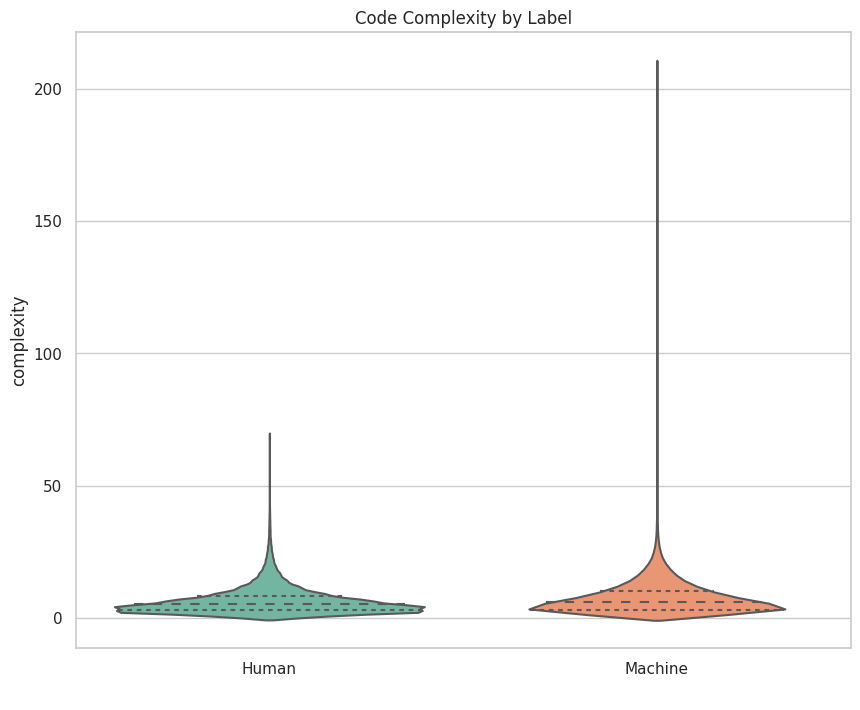

In [116]:
def complexity_score(text):
    score = 0
    score += text.count("for")
    score += text.count("while")
    score += text.count("if")
    score += text.count("elif")
    score += text.count("class")
    score += text.count("def")
    return score

train_data["complexity"] = train_data[train_data["code_length"] < train_data["code_length"].quantile(0.90)]["code"].astype(str).apply(complexity_score)
plt.figure(figsize=(10, 8))
sns.violinplot(
    x="label",
    y="complexity",
    data=train_data,
    inner="quartile",
    palette="Set2"
)
plt.xticks([0,1], ["Human", "Machine"])
plt.xlabel(" ")
plt.title("Code Complexity by Label")
plt.show()

## WordCloud: Human And Machine

Text(0.5, 1.0, 'Human Code WordCloud')

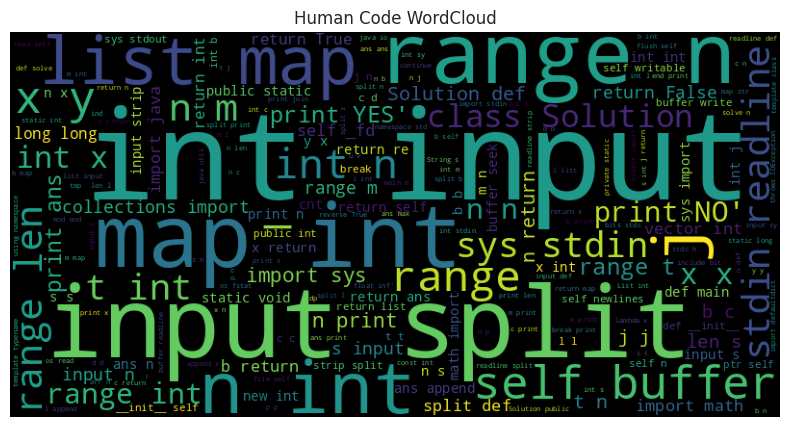

In [39]:
# Human-written code

from wordcloud import WordCloud
wc_human = WordCloud(width=800, height=400).generate(" ".join(train_data[train_data.label==0].code.astype(str)))
plt.imshow(wc_human); plt.axis("off"); plt.title("Human Code WordCloud")


Text(0.5, 1.0, 'Machine Code WordCloud')

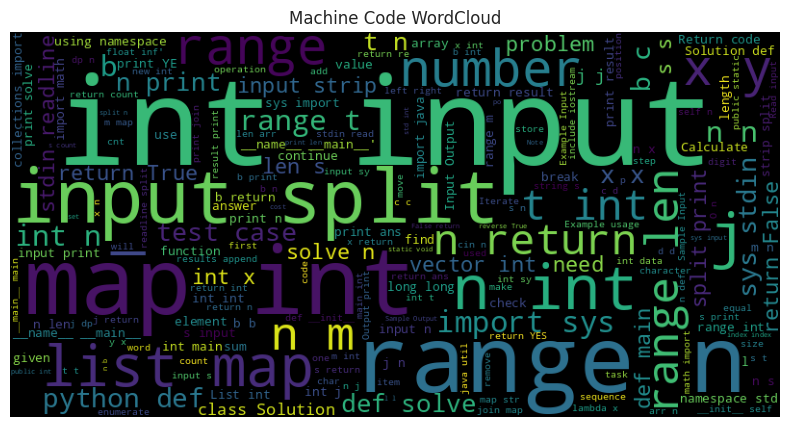

In [40]:
# Machine-generated code
wc_llm = WordCloud(width=800, height=400).generate(" ".join(train_data[train_data.label==1].code.astype(str)))
plt.imshow(wc_llm); plt.axis("off"); plt.title("Machine Code WordCloud")
